# Reproducing Mattar & Daw (2018): forward vs. reverse replay

Mattar, M. G., & Daw, N. D. (2018). "Prioritized memory access explains planning
and hippocampal replay." *Nature Neuroscience*. (PDF in repo root:
`s41593-018-0232-z (1).pdf`)

This notebook drives `unc_pma.agents.PMAagent` on the paper's own two tasks
(Methods, "Simulation details") and reproduces the qualitative claims of:

- **Figure 2** — planning bouts form *extended, directional* replay
  trajectories: chained backward after an unexpected reward (reverse replay),
  chained forward before departing (forward replay) — an emergent consequence
  of recomputing Gain and Need from the current Q-table and model at every
  planning iteration, not a separate mechanism for each direction.
- **Figure 3** — forward sequences concentrate *before* a run starts, reverse
  sequences concentrate *after* a run ends (right when reward is received).

**Tasks** (paper's exact parameters): a 1x10 linear-track corridor and
Sutton's 6x9 Dyna maze, both driven with softmax action selection (beta=5),
alpha=1.0, gamma=0.9, 20 planning steps executed at the start and the end of
each episode only (`auto_plan=False`, explicit `agent.plan()` calls), and a
model that is exhaustively pre-explored before the first episode (matching
the paper's initialization "with a full set of experiences corresponding to
executing every action in every state").


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from unc_pma.environments import NoisyGridworld
from unc_pma.agents import PMAagent

np.random.seed(0)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Colorblind-safe categorical pair (Okabe-Ito), used consistently everywhere below
COLOR_FORWARD = "#0072B2"
COLOR_REVERSE = "#E69F00"


## Helper functions

- `exhaustive_pre_explore`: seeds the agent's model with every (state, action)
  transition up front (reward always recorded as 0, matching the paper — the
  agent doesn't yet know *where* reward is, only *how the world moves*), and
  separately seeds a goal -> next-start transition directly into `T` (not as a
  real candidate action) so the Need term correctly anticipates the agent's
  return after reward, exactly like the reference implementation's
  `Tgoal2start` and its explicit exclusion of the goal state from planning
  candidates.
- `classify_backups`: Mattar & Daw's rule for labeling each executed backup as
  forward or reverse by comparing it to the *next* backup in the sequence.
- `run_episode_with_bouts`: runs one real episode, with a 20-step planning
  bout immediately before departure and immediately after reward — matching
  "the agent is allowed 20 planning steps at the beginning and at the end of
  each episode" (Methods).
- `run_simulation`: repeats this over many episodes and seeds, collecting
  per-bout forward/reverse counts and a couple of example bouts to visualize.


In [2]:
def exhaustive_pre_explore(agent: PMAagent, env: NoisyGridworld) -> None:
    """Seed the model with every (state, action) transition, reward=0, before any real experience.

    Also seeds a uniform goal -> valid-start-state transition directly into
    T (bypassing candidate generation), so Need is well-defined immediately
    after the agent reaches any goal.
    """
    wall_states = {r * env.width + c for (r, c) in env.walls}
    goal_states = set(env.goal_encoded_states)

    for s in range(env.n_states):
        if s in goal_states or s in wall_states:
            continue
        for a in range(env.n_actions):
            next_state, _, _ = env.deterministic_transition(s, a)
            agent.model.update(s, a, 0.0, next_state)

    valid_encoded = [r * env.width + c for (r, c) in env.valid_states]
    start_distribution = np.zeros(env.n_states)
    start_distribution[valid_encoded] = 1.0 / len(valid_encoded)
    for g in goal_states:
        for a in range(env.n_actions):
            agent.model.set_transition(g, a, start_distribution.copy())


def classify_backups(transitions: list) -> list:
    """Label each backup (but the last) as 'forward', 'reverse', or None.

    Forward:  the next backup starts where this one ended.
    Reverse:  the next backup's target is where this one started.
    (Mattar & Daw 2018, Methods: "Identification of significant replay events".)
    """
    labels = [None] * len(transitions)
    for i in range(len(transitions) - 1):
        cur, nxt = transitions[i], transitions[i + 1]
        if nxt.state == cur.next_state:
            labels[i] = "forward"
        elif nxt.next_state == cur.state:
            labels[i] = "reverse"
    return labels


def run_episode_with_bouts(agent: PMAagent, env: NoisyGridworld, state: int, max_steps: int = 20_000):
    """One episode: plan before departing, run to reward, plan after arriving.

    Also returns the Need row (successor-representation row from each bout's
    starting state, `agent.last_sr[agent.last_plan_origin_state]`) alongside
    each bout, since that's what should be visualized as the spatial gradient
    (see `plot_example_bout`) — Gain alone doesn't have that structure.
    """
    agent._current_state = state
    before_bout = agent.plan(n_steps=agent.n_plan)
    before_need = (agent.last_sr[agent.last_plan_origin_state].copy()
                   if agent.last_sr is not None else None)

    done = False
    steps = 0
    while not done and steps < max_steps:
        action = agent.select_action(state)
        next_state, reward, done, _ = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state
        steps += 1

    agent._current_state = state
    after_bout = agent.plan(n_steps=agent.n_plan)
    after_need = (agent.last_sr[agent.last_plan_origin_state].copy()
                  if agent.last_sr is not None else None)
    return state, steps, before_bout, before_need, after_bout, after_need


def run_simulation(make_env, agent_kwargs: dict, n_episodes: int, n_seeds: int):
    """Repeat `run_episode_with_bouts` over many episodes/seeds; collect stats and examples."""
    steps_per_episode = np.zeros((n_seeds, n_episodes))
    counts = {
        "before": {"forward": np.zeros((n_seeds, n_episodes)), "reverse": np.zeros((n_seeds, n_episodes))},
        "after": {"forward": np.zeros((n_seeds, n_episodes)), "reverse": np.zeros((n_seeds, n_episodes))},
    }
    example_before = example_after = None
    example_before_need = example_after_need = None

    for seed in range(n_seeds):
        np.random.seed(seed)
        env = make_env()
        agent = PMAagent(n_states=env.n_states, n_actions=env.n_actions, **agent_kwargs)
        exhaustive_pre_explore(agent, env)

        state = env.reset()
        for ep in range(n_episodes):
            state, steps, before_bout, before_need, after_bout, after_need = run_episode_with_bouts(
                agent, env, state
            )
            steps_per_episode[seed, ep] = steps

            before_labels = classify_backups([traj[-1] for traj, _, _ in before_bout])
            after_labels = classify_backups([traj[-1] for traj, _, _ in after_bout])
            counts["before"]["forward"][seed, ep] = before_labels.count("forward")
            counts["before"]["reverse"][seed, ep] = before_labels.count("reverse")
            counts["after"]["forward"][seed, ep] = after_labels.count("forward")
            counts["after"]["reverse"][seed, ep] = after_labels.count("reverse")

            if seed == 0 and ep == 0:
                example_after, example_after_need = after_bout, after_need
            if seed == 0 and example_before is None and sum(
                1 for l in before_labels if l == "forward"
            ) >= 3:
                example_before, example_before_need = before_bout, before_need

            state = env.reset()

    return (steps_per_episode, counts,
            example_before, example_before_need,
            example_after, example_after_need)


In [3]:
def plot_fig3_bar(counts: dict, title: str):
    """Grouped bar chart matching Fig. 3a: mean events/episode, Forward/Reverse x Before/After."""
    means = {
        "before_forward": counts["before"]["forward"].mean(),
        "before_reverse": counts["before"]["reverse"].mean(),
        "after_forward": counts["after"]["forward"].mean(),
        "after_reverse": counts["after"]["reverse"].mean(),
    }
    sems = {
        k: counts[phase][direction].std() / np.sqrt(counts[phase][direction].size)
        for k, (phase, direction) in zip(
            means, [("before", "forward"), ("before", "reverse"), ("after", "forward"), ("after", "reverse")]
        )
    }

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    x = np.array([0, 1])
    width = 0.35

    before_vals = [means["before_forward"], means["before_reverse"]]
    after_vals = [means["after_forward"], means["after_reverse"]]
    before_errs = [sems["before_forward"], sems["before_reverse"]]
    after_errs = [sems["after_forward"], sems["after_reverse"]]

    bars_before = ax.bar(x - width / 2, before_vals, width, yerr=before_errs, capsize=3,
                          color="#BBBBBB", label="Before run", edgecolor="white")
    bars_after = ax.bar(x + width / 2, after_vals, width, yerr=after_errs, capsize=3,
                         color="#555555", label="After run", edgecolor="white")

    for bars in (bars_before, bars_after):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{height:.2f}", (bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(["Forward replay", "Reverse replay"])
    ax.set_ylabel("Mean number of events per bout")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_learning_curve(steps_per_episode: np.ndarray, title: str):
    """Steps-to-reward per episode, matching Fig. 1e's learning-speed claim."""
    mean_steps = steps_per_episode.mean(axis=0)
    sem_steps = steps_per_episode.std(axis=0) / np.sqrt(steps_per_episode.shape[0])
    episodes = np.arange(1, len(mean_steps) + 1)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(episodes, mean_steps, color=COLOR_FORWARD, lw=2)
    ax.fill_between(episodes, mean_steps - sem_steps, mean_steps + sem_steps, color=COLOR_FORWARD, alpha=0.15)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Steps to reward")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


In [4]:
def plot_example_bout(bout: list, env: NoisyGridworld, title: str, need_row: np.ndarray | None = None):
    """Fig. 2-style diagram: one arrow per executed backup, numbered in execution order.

    Matches the reference implementation's two-layer scheme
    (`replaySim.m`'s `plotMazeWithArrows(st, SR_or_SD, saGain, ...)`): the
    maze **background** is shaded by *Need* (`need_row`, the successor-
    representation row from the bout's starting state, normalized to its own
    max over non-wall states) — Need is what produces the smooth spatial
    gradient radiating from wherever the agent currently is (highest just
    ahead of it), which is why "before run" (forward) bouts look like a
    gradient centered on the start state. Gain is only a **per-state
    overlay** here (a red dot at each backed-up state, sized by Gain
    normalized to the largest Gain in this bout) — for a Need-driven forward
    bout, Gain has no reason to form a spatial gradient by itself, so an
    earlier version of this function that shaded the *background* by Gain
    instead of Need looked essentially like noise for forward bouts.

    Arrows are colored by the forward/reverse classification of the backup
    that precedes them in the sequence (the last backup can't be classified).
    """
    transitions = [traj[-1] for traj, _, _ in bout]
    gains = [max(gain, 0.0) for _, _, gain in bout]
    labels = classify_backups(transitions)

    max_gain = max(gains) if gains else 0.0
    state_gain = {}
    for exp, gain in zip(transitions, gains):
        norm_gain = gain / max_gain if max_gain > 0 else 0.0
        state_gain[exp.state] = max(state_gain.get(exp.state, 0.0), norm_gain)

    non_wall_states = [env._encode(r, c) for r in range(env.height) for c in range(env.width)
                        if (r, c) not in env.walls]
    max_need = (max(need_row[s] for s in non_wall_states)
                if need_row is not None and non_wall_states else 0.0)

    fig, ax = plt.subplots(figsize=(max(4, env.width * 0.7), max(3, env.height * 0.7)))

    for (r, c) in [(r, c) for r in range(env.height) for c in range(env.width)]:
        face = "#DDDDDD" if (r, c) in env.walls else "white"
        ax.add_patch(plt.Rectangle((c - 0.5, -r - 0.5), 1, 1, facecolor=face, edgecolor="#CCCCCC"))
        if need_row is not None and (r, c) not in env.walls and max_need > 0:
            need_alpha = need_row[env._encode(r, c)] / max_need
            ax.add_patch(plt.Rectangle((c - 0.5, -r - 0.5), 1, 1,
                                        facecolor="#3182BD", alpha=0.8 * need_alpha, edgecolor="none"))
        gain_alpha = state_gain.get(env._encode(r, c), 0.0)
        if gain_alpha > 0:
            ax.add_patch(plt.Circle((c, -r), 0.05 + 0.18 * gain_alpha,
                                     facecolor="red", alpha=0.85, edgecolor="none"))
    for (r, c) in env.goals:
        ax.add_patch(plt.Rectangle((c - 0.5, -r - 0.5), 1, 1, facecolor="none", edgecolor="black", lw=2))

    color_map = {"forward": COLOR_FORWARD, "reverse": COLOR_REVERSE, None: "#999999"}
    for i, exp in enumerate(transitions):
        r0, c0 = env._decode(exp.state)
        r1, c1 = env._decode(exp.next_state)
        color = color_map[labels[i]]
        if (r0, c0) == (r1, c1):
            continue  # self-loop, nothing to draw
        ax.annotate(
            "", xy=(c1, -r1), xytext=(c0, -r0),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.8,
                             shrinkA=8, shrinkB=8, alpha=0.5 + 0.5 * i / len(transitions)),
        )
        ax.text((c0 + c1) / 2, -(r0 + r1) / 2, str(i + 1), color=color, fontsize=8,
                ha="center", va="center", fontweight="bold")

    ax.set_xlim(-0.6, env.width - 0.4)
    ax.set_ylim(-env.height + 0.4, 0.6)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    handles = [
        plt.Line2D([0], [0], color=COLOR_FORWARD, lw=2, label="Forward"),
        plt.Line2D([0], [0], color=COLOR_REVERSE, lw=2, label="Reverse"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#3182BD", alpha=0.6, edgecolor="none", label="Need (normalized)"),
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="red", markersize=8,
                   label="Gain (normalized)"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=4, frameon=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## Linear track (1x10 corridor)

The paper simulates the track as two disjoint, direction-specific 1x10
segments purely to give hippocampal place cells a direction-selective code
(so forward vs. reverse replay is unambiguous in the neural data being
compared against) — that detail isn't needed to reproduce the *replay
statistics* themselves, so here it's just a single `NoisyGridworld` corridor
(`height=1, width=10`): start at one end, unit reward (+ N(0, 0.1) noise) at
the other, reset back to the start on arrival. `height=1` makes the up/down
actions self-loops for free (no vertical extent to move into).


In [5]:
TRACK_LENGTH = 10

def make_track_env():
    return NoisyGridworld(
        height=1, width=TRACK_LENGTH, start=(0, 0), goals={(0, TRACK_LENGTH - 1): 1.0},
        walls=set(), slip_prob=0.0, reward_noise=0.1, step_cost=0.0,
        reward_noise_at_goal_only=True,
    )

# Paper's exact parameters (Methods: Simulation details)
PAPER_AGENT_KWARGS = dict(
    gamma=0.9, alpha=1.0,
    policy="softmax", softmax_beta=5.0,
    off_policy=True,
    n_plan=20, auto_plan=False,
    baseline_gain=1e-10, evb_threshold=0.0,
    t_learning_rate=0.9,
    expand_further=True, allow_loops=False,
    skip_self_transitions=True,
)

(track_steps, track_counts,
 track_example_before, track_example_before_need,
 track_example_after, track_example_after_need) = run_simulation(
    make_track_env, PAPER_AGENT_KWARGS, n_episodes=50, n_seeds=15,
)
print("Linear track simulation done.")
print("Mean steps to reward, episode 1 vs episode 50:",
      track_steps[:, 0].mean(), "->", track_steps[:, -1].mean())


Linear track simulation done.
Mean steps to reward, episode 1 vs episode 50: 201.73333333333332 -> 44.333333333333336


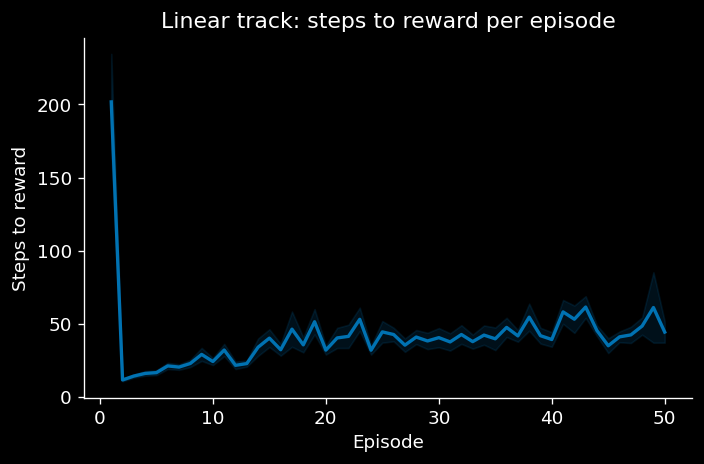

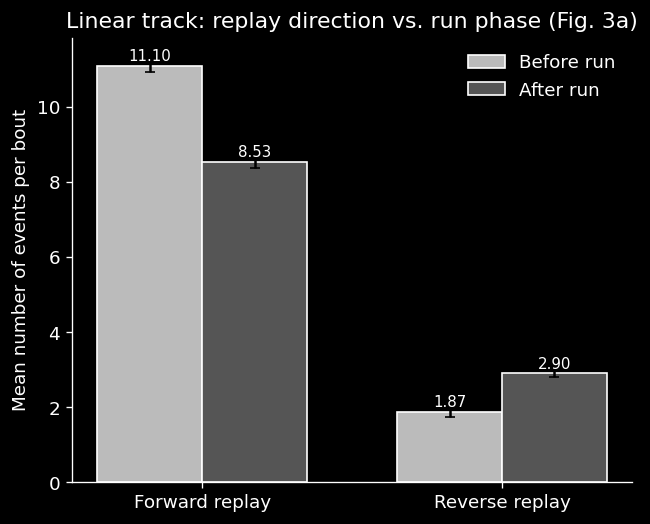

In [6]:
plot_learning_curve(track_steps, "Linear track: steps to reward per episode")
plot_fig3_bar(track_counts, "Linear track: replay direction vs. run phase (Fig. 3a)")


### Example replay bouts (Fig. 2 style)

Right after the very first reward, the "after run" bout should chain
*backward* from the agent's position, one step at a time, with growing EVB —
Gain propagating to each predecessor in turn. Once Gain has flattened out
(no more prediction error left to correct), a "before run" bout is instead
driven purely by Need, which is highest just ahead of the agent — producing a
*forward*-growing chain instead.


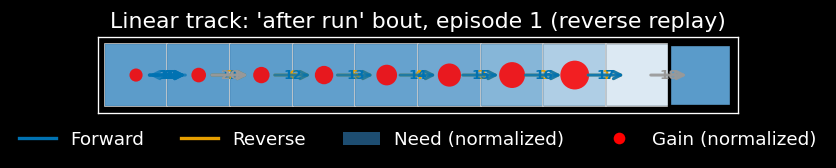

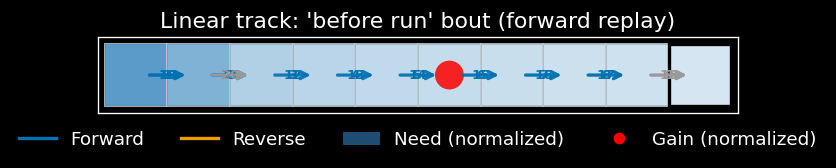

In [7]:
track_env_for_plot = make_track_env()
plot_example_bout(track_example_after, track_env_for_plot,
                   "Linear track: 'after run' bout, episode 1 (reverse replay)",
                   need_row=track_example_after_need)
if track_example_before is not None:
    plot_example_bout(track_example_before, track_env_for_plot,
                       "Linear track: 'before run' bout (forward replay)",
                       need_row=track_example_before_need)
else:
    print("No forward-dominated 'before run' example found in episode 0's seed; "
          "try increasing n_episodes or inspect track_counts directly.")


## Two-dimensional maze (Sutton's Dyna maze, 6x9)

Same wall layout as `runSimulation_openMaze.m`: start (row 2, col 0),
goal (row 0, col 8), walls forming two partial barriers. Unlike the track,
the start location is **randomized every episode** (`random_start=True`),
matching the paper's maze setup — so the "before run" bout now also
sometimes has real, above-floor Gain (new start locations can be genuinely
informative), not just Need.


In [8]:
def make_maze_env():
    return NoisyGridworld(
        height=6, width=9, start=(2, 0), goals={(0, 8): 1.0},
        walls={(1, 2), (2, 2), (3, 2), (0, 7), (1, 7), (2, 7), (4, 5)},
        slip_prob=0.0, reward_noise=0.1, step_cost=0.0,
        random_start=True, reward_noise_at_goal_only=True,
    )

(maze_steps, maze_counts,
 maze_example_before, maze_example_before_need,
 maze_example_after, maze_example_after_need) = run_simulation(
    make_maze_env, PAPER_AGENT_KWARGS, n_episodes=50, n_seeds=15,
)
print("Maze simulation done.")
print("Mean steps to reward, episode 1 vs episode 50:",
      maze_steps[:, 0].mean(), "->", maze_steps[:, -1].mean())


Maze simulation done.
Mean steps to reward, episode 1 vs episode 50: 742.6666666666666 -> 48.2


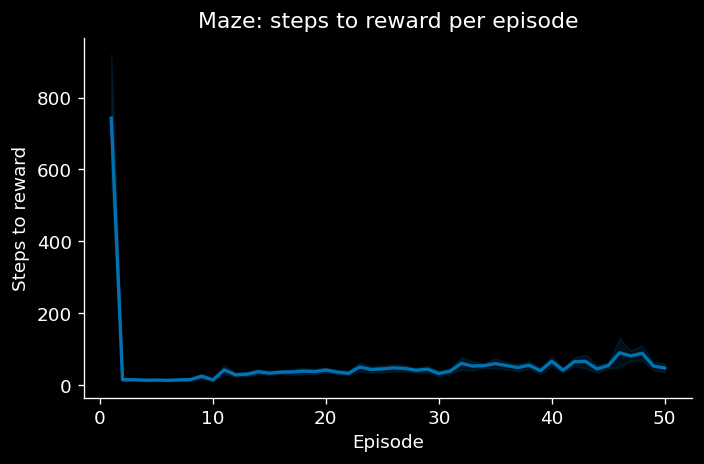

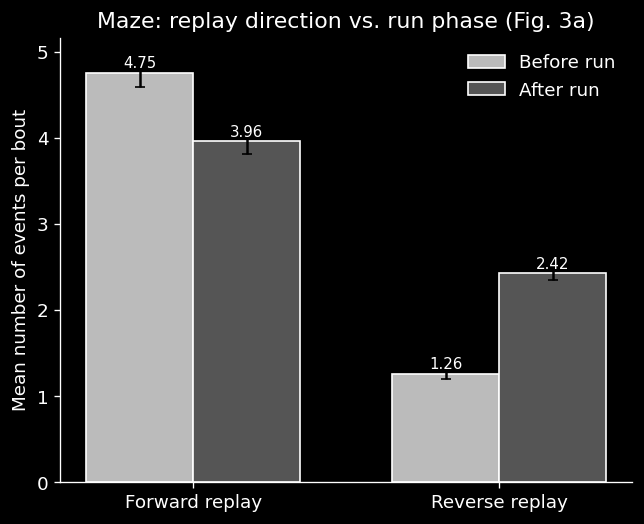

In [9]:
plot_learning_curve(maze_steps, "Maze: steps to reward per episode")
plot_fig3_bar(maze_counts, "Maze: replay direction vs. run phase (Fig. 3a)")


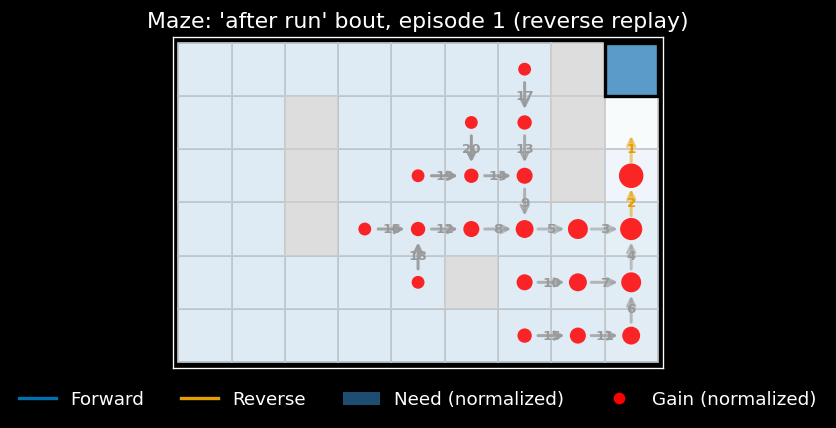

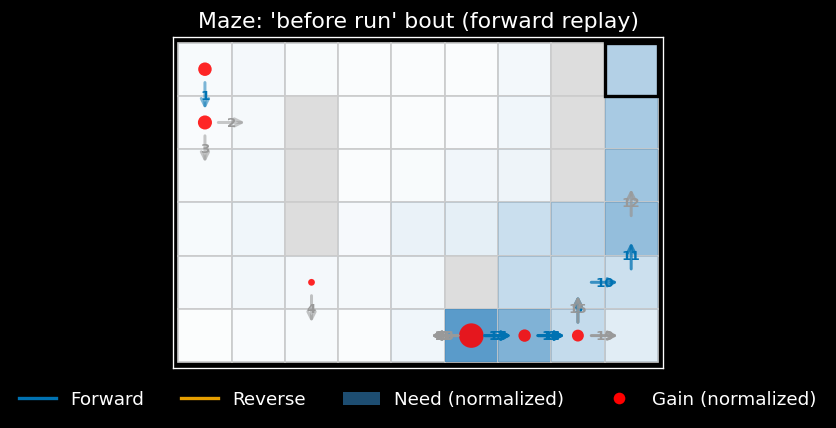

In [10]:
maze_env_for_plot = make_maze_env()
plot_example_bout(maze_example_after, maze_env_for_plot,
                   "Maze: 'after run' bout, episode 1 (reverse replay)",
                   need_row=maze_example_after_need)
if maze_example_before is not None:
    plot_example_bout(maze_example_before, maze_env_for_plot,
                       "Maze: 'before run' bout (forward replay)",
                       need_row=maze_example_before_need)
else:
    print("No forward-dominated 'before run' example found in episode 0's seed; "
          "try increasing n_episodes or inspect maze_counts directly.")


## Summary

- **Learning curve**: steps-to-reward drops sharply after episode 1 in both
  tasks (prioritized sweeping propagates value the moment reward is found),
  matching the paper's Fig. 1e claim about learning speed.
- **Fig. 3 reproduction**: "before run" bouts are forward-dominated and
  "after run" bouts are reverse-dominated, in both the corridor and the maze
  — with no special-cased "forward mode" / "reverse mode" logic anywhere in
  `PMAagent`. Both patterns emerge from the *same* mechanism (recomputing
  Gain and Need for every candidate at every planning iteration, plus the
  one-step chain extension), which is exactly the paper's point: reverse
  replay is prioritized sweeping's natural response to a fresh prediction
  error (Gain concentrates behind the agent, at the just-updated state's
  predecessors), while forward replay is what Need alone produces once Gain
  has flattened out (Need is always highest just ahead of wherever the agent
  currently is).
- **Fig. 2 reproduction**: the example bouts show EVB growing monotonically
  as the reverse chain in the corridor propagates backward link-by-link, and
  a genuine forward-extending chain once gain differences are negligible —
  both are single-experience-at-a-time replays stitched together by
  `PMAagent`'s chaining mechanism (`expand_further`), not distinct
  algorithms.

**Caveats / simplifications relative to the paper**, worth flagging if this
is extended further:
- No permutation-based significance test for "replay events" (Methods,
  "Identification of significant replay events") — every classified backup
  is counted, not just runs of length >= 5.
- The linear track is one directional corridor rather than the paper's two
  disjoint direction-coded segments (a place-cell-realism detail, not needed
  for the replay-direction statistics reproduced here — see the
  clarifying discussion earlier in this notebook).
- `TabularEnvironmentModel` has no uncertainty over T or R — a natural next
  step, given this repo's Bayesian Q-learning agent (`unc_pma.bayesian_qlearning`),
  is a Bayesian world model whose *posterior uncertainty* over the model
  itself could enter the Gain/Need computation.
